In [76]:
import pandas as pd

!apt-get update -qq
!apt-get install -y -qq glpk-utils
import pyomo.environ as pyo
from google.colab import files
uploaded=files.upload()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving Data.xlsx to Data (4).xlsx


In [77]:
P=pd.read_excel("Data.xlsx")
P.columns=P.columns.str.strip()
print(P.columns)

model = pyo.ConcreteModel()

Index(['Product', 'Profit (€ / Unit)', 'Processing Hours / Unit',
       'Maximum Demand'],
      dtype='object')


In [78]:
from pyomo.core.base.objective import maximize
from pyomo.core.base.set_types import NonNegativeIntegers
model.P=pyo.Set(initialize=P["Product"].tolist())
model.Profit=pyo.Param(model.P,initialize=P.set_index("Product")["Profit (€ / Unit)"].to_dict())
model.Processing_Hours=pyo.Param(model.P,initialize=P.set_index("Product")["Processing Hours / Unit"].to_dict())
model.Maximum_Demand=pyo.Param(model.P,initialize=P.set_index("Product")["Maximum Demand"].to_dict())
model.RegularCapacity = pyo.Param(initialize=20000)
model.MaxOvertime = pyo.Param(initialize=4000)
model.OvertimeCost = pyo.Param(initialize=25)

#Decision Variable
model.x=pyo.Var(model.P,within=pyo.NonNegativeIntegers)
model.OT=pyo.Var(within=pyo.NonNegativeReals)

#Objective Function
def Objective_rule(model):
    return sum(model.Profit[p] * model.x[p] for p in model.P) - 25 * model.OT

model.Objective = pyo.Objective(rule=Objective_rule,sense=pyo.maximize)

#Constraint
def Capacity_rule(model):
    return sum(model.Processing_Hours[p] * model.x[p] for p in model.P) <= model.RegularCapacity + model.OT

model.Capacity_constraint = pyo.Constraint(rule=Capacity_rule)

def Overtime_rule(model):
    return model.OT <= model.MaxOvertime

model.Overtime_constraint = pyo.Constraint(rule=Overtime_rule)

def Demand_rule(model, p):
    return model.x[p] <= model.Maximum_Demand[p]

model.Demand_constraint = pyo.Constraint(
    model.P,
    rule=Demand_rule
)



In [79]:
solver = pyo.SolverFactory(
    "glpk",
    executable="/usr/bin/glpsol"
)

print("GLPK available:", solver.available())
results=solver.solve(model)
print("Status:" , results.solver.Status)
print("Termination:", results.solver.termination_condition)

GLPK available: True
Status: ok
Termination: optimal


In [88]:
#How many units of each product should the company produce?
results = []

for p in model.P:
    results.append({
        "Product": p,
        "Production": pyo.value(model.x[p])
    })

results_df = pd.DataFrame(results)

results_df




,Product,Production
0,Chocolate Bar,12000.0
1,Biscuit Pack,10000.0
2,Potato Chips,8000.0
3,Energy Drink,7000.0
4,Fruit Juice,7500.0
5,Breakfast Cereal,0.0
6,Instant Noodles,11000.0
7,Coffee Pack,0.0
8,Tea Box,0.0
9,Protein Bar,0.0


In [95]:
#Question 2 — How many overtime hours are used?
print("Over Time:",pyo.value(model.OT))

#calculate the total production profit before overtime cost.
production_profit = sum(
    pyo.value(model.Profit[p]) * pyo.value(model.x[p])
    for p in model.P
)

print("Production Profit:", production_profit)
overtime_cost = pyo.value(model.OvertimeCost) * pyo.value(model.OT)

print("Overtime Cost:", overtime_cost)



Over Time: 0.0
Production Profit: 310050.0
Overtime Cost: 0.0


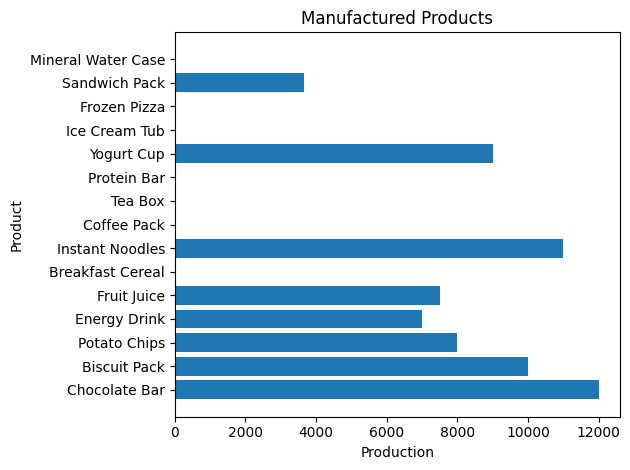

In [99]:
import matplotlib.pyplot as plt
x=list(model.P)
y=[pyo.value(model.x[p]) for p in model.P]
plt.barh(x,y)
plt.xlabel("Production")
plt.ylabel("Product")
plt.title("Manufactured Products")
plt.tight_layout()
plt.show()